Importing project from GoogleDrive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import necessary libraries

In [4]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
from pathlib import Path
import os
import sys
import cv2
from google.colab.patches import cv2_imshow

project_dir = '/content/drive/MyDrive/Hand_Gesture_Project'
sys.path.append(project_dir)


# FOR MY DATASET
# from utils.split_classification import split_classification_dataset

# FOR MY DATASET + ADDED ELVIN'S REDACTED DATASET
from utils.split_classification_added_elvin import split_classification_dataset

# IMPORTS OF OTHER UTILS
from utils.classification_augmentations import get_train_augmentations, get_val_augmentations
from utils.classification_generator import ClassificationDataset
from utils.classification_model_builder import build_transfer_mobilenetv2

Getting the dataset for classification

In [5]:
# FOR MY DATADET
# data_zip_path = os.path.join(project_dir, 'data/data.zip')

# FOR MY DATASET + ADDED ELVIN'S REDACTED DATASET
data_zip_path = os.path.join(project_dir, 'data/data_added_elvin.zip')
!unzip {data_zip_path} -d /content/data

Archive:  /content/drive/MyDrive/Hand_Gesture_Project/data/data_added_elvin.zip
   creating: /content/data/dataset_classification/
   creating: /content/data/dataset_classification/0/
  inflating: /content/data/dataset_classification/0/img_onlyhand_001-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_007-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_013-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_019-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_025-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_031-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_037-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_043-rectangle.jpg  
  inflating: /content/data/dataset_classification/0/img_onlyhand_049-rectangle.jpg  
  inflating: /content/data/dataset_classification/0

Defining paths for the raw dataset directory and output directory

In [6]:
raw_data_dir = "/content/data/dataset_classification"
output_dir = "/content/data/dataset_classification_split"

Optional line (to delete the split and start over)

In [ ]:
!rm -r /content/data/dataset_classification_split

Splitting data into train,validation and test sets

In [7]:
split_classification_dataset(
    raw_dir=raw_data_dir,
    output_dir=output_dir,
    ratios=(0.7,0.2,0.1)
)

Class 5: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18
Class 0: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18
Class 4: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18
Class 1: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18
Class 3: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18
Class 2: train=62, val=17, test=13 | onlyhand=37, selfie=37, photo=18

Dataset split completed:
Train images: 372
Val images:   102
Test images:  78
Total:        552


Defining paths for image generator

In [8]:
output_dir = Path("data/dataset_classification_split")
train_dir = output_dir / "train"
val_dir = output_dir / "val"
test_dir = output_dir / "test"

Batch size for generator

In [9]:
batch_size = 16

Getting augmentations for train set and validation/test set

In [10]:
train_augs = get_train_augmentations(img_size=224)  # With augmentations for training
val_augs = get_val_augmentations(img_size=224)      # Only resize for val/test

Creating datasets using generators and augmentation functions

In [11]:
train_dataset = ClassificationDataset(
    root_dir=train_dir,
    batch_size=batch_size,
    augmentations=train_augs,  # Augmentations only for train
    shuffle=True,
    num_classes=6
)

val_dataset = ClassificationDataset(
    root_dir=val_dir,
    batch_size=batch_size,
    augmentations=val_augs,  # Only resize
    shuffle=False,           # No shuffle for val
    num_classes=6
)

test_dataset = ClassificationDataset(
    root_dir=test_dir,
    batch_size=batch_size,
    augmentations=val_augs,  # Only resize
    shuffle=False,           # No shuffle for test
    num_classes=6
)

Extra checks to see if the generator works correctly

In [12]:
x_batch, y_batch = train_dataset[0]
print("x_batch shape:", x_batch.shape)
print("y_batch shape:", y_batch.shape)

labels_idx = np.argmax(y_batch, axis=1)
print("Labels in batch:", labels_idx)

x_batch shape: (16, 224, 224, 3)
y_batch shape: (16, 6)
Labels in batch: [1 1 0 4 3 0 3 2 4 3 2 1 1 3 3 3]


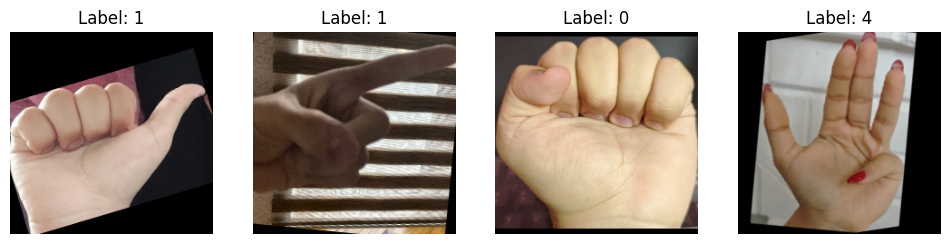

In [13]:
plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow((x_batch[i] + 1)/2)
    plt.title(f"Label: {labels_idx[i]}")
    plt.axis("off")
plt.show()

In [ ]:
last_idx = len(train_dataset) - 1
x_last, y_last = train_dataset[last_idx]
print("Last batch x shape:", x_last.shape)
print("Last batch y shape:", y_last.shape)

Last batch x shape: (12, 224, 224, 3)
Last batch y shape: (12, 6)


Model Parameters (All parameters were determined via hyperparameter tuning with Keras Optuna)

In [14]:
IMG_SIZE = 224
NUM_CLASSES = 6
EPOCHS = 50
BASE_LR = 0.008115748913403031
FT_LR = 9.510782648161585e-05
DROPOUT_RATE = 0.5834648527266535
NUM_FT_LAYERS = 39

Creating folder for checkpoints (if it does not exists)

In [15]:
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

Building the model using build_transfer_mobilenetv2 function from utils

In [56]:
model = build_transfer_mobilenetv2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    num_classes=NUM_CLASSES,
    dropout_rate=DROPOUT_RATE,
    trainable_layers=0
)

model.summary()

Model: "MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,486 (9.87 MB)

 Trainable params: 329,990 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

Compiling the model

In [57]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=BASE_LR),
    loss = keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

Defining callbacks

In [58]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(CHECKPOINT_DIR, "best_mobilenetv2.keras"),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

Training the model’s head layers

In [59]:
# Train the model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.3005 - loss: 7.0544
Epoch 1: val_loss improved from inf to 7.94262, saving model to checkpoints/best_mobilenetv2.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 649ms/step - accuracy: 0.3037 - loss: 7.0548 - val_accuracy: 0.4608 - val_loss: 7.9426 - learning_rate: 0.0081
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.4561 - loss: 6.2625
Epoch 2: val_loss improved from 7.94262 to 4.77229, saving model to checkpoints/best_mobilenetv2.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 591ms/step - accuracy: 0.4571 - loss: 6.2397 - val_accuracy: 0.5294 - val_loss: 4.7723 - learning_rate: 0.0081
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.5458 - loss: 4.1673
Epoch 3: val_loss improved from 4.77229 to 3.33278, saving model to checkpoints/best_mobilenetv2.keras
24/24 ━━━━━━━━━━━━━━━━━━━━ 14s 609ms/step - accuracy: 0.5466 - loss: 4.1558 - val_accuracy: 0.5980 - val_loss: 3.3328 - learning_rate: 0.0081
Epoch 4/50


Fine-tuning: unfreezing the last 39 layers of the base model

In [60]:
base_model = model.get_layer(name="mobilenetv2_1.00_224")

fine_tune_at = len(base_model.layers) - NUM_FT_LAYERS

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

for layer in base_model.layers[fine_tune_at:]:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True

Recompile with lower learning rate

In [61]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=FT_LR),
    loss = keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

model.summary()

Model: "MobileNetV2_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,588,486 (9.87 MB)

 Trainable params: 1,993,350 (7.60 MB)

 Non-trainable params: 595,136 (2.27 MB)

Fine-tuning: training

In [62]:
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=50,  # Additional epochs
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.7694 - loss: 1.1251
Epoch 1: val_loss did not improve from 1.11596
24/24 ━━━━━━━━━━━━━━━━━━━━ 25s 813ms/step - accuracy: 0.7662 - loss: 1.1318 - val_accuracy: 0.6373 - val_loss: 1.3200 - learning_rate: 9.5108e-05
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.7323 - loss: 1.2203
Epoch 2: val_loss did not improve from 1.11596
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s 681ms/step - accuracy: 0.7313 - loss: 1.2190 - val_accuracy: 0.3333 - val_loss: 2.5135 - learning_rate: 9.5108e-05
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - accuracy: 0.7621 - loss: 1.0473
Epoch 3: val_loss did not improve from 1.11596
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 726ms/step - accuracy: 0.7614 - loss: 1.0483 - val_accuracy: 0.5196 - val_loss: 2.1554 - learning_rate: 9.5108e-05
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.8236 - loss: 0.8945
Epoch 4: val_loss did not improve from 1.11596
24/24 ━━━━━━━━━━━━━━━━━━━━ 16s

Saving the model

In [64]:
save_dir = os.path.join(project_dir, "models", "classification")
os.makedirs(save_dir, exist_ok=True)

In [65]:
model_save_path = os.path.join(
    save_dir,
    "mobilenetv2_best_added_elvin.keras"
)

In [66]:
model.save(model_save_path)

Testing the model

In [63]:
model = keras.models.load_model('/content/checkpoints/best_mobilenetv2.keras')

test_loss, test_accuracy = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 398ms/step - accuracy: 0.9690 - loss: 0.3517
Test Loss: 0.3960
Test Accuracy: 0.9487


The training histories were merged into one, as they correspond to the same model

In [69]:
loss = history.history['loss'] + history_fine.history['loss']
val_loss = history.history['val_loss'] + history_fine.history['val_loss']

accuracy = history.history['accuracy'] + history_fine.history['accuracy']
val_accuracy = history.history['val_accuracy'] + history_fine.history['val_accuracy']

epochs = range(1, len(loss) + 1)

Loss curves for the history and history_fine training phases. The plot corresponds to the model from the first run, which achieved 91% accuracy on the test set.

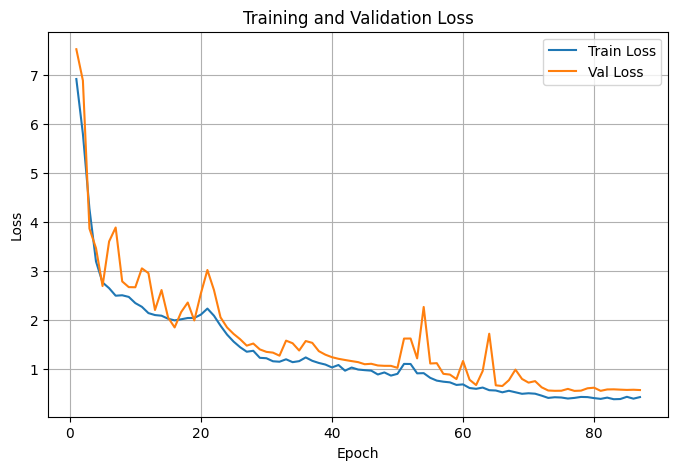

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

After several runs without changing any hyperparameters, a slightly better model was obtained due to randomness in training. The model achieved 93% accuracy, although with a higher loss, as shown in the training history plot.

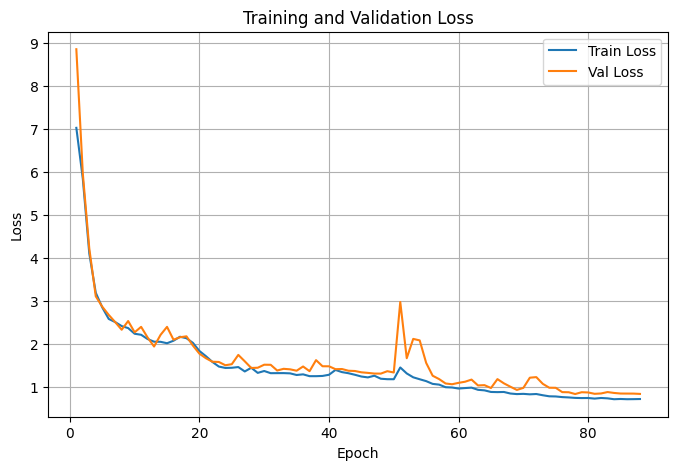

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

After adding Elvin Mahmudzada's data to mine, I achieved almost 95% accuracy, and the loss on the test set decreased to 0.3960, making the model more confident in its predictions. This is the loss plot of that model.

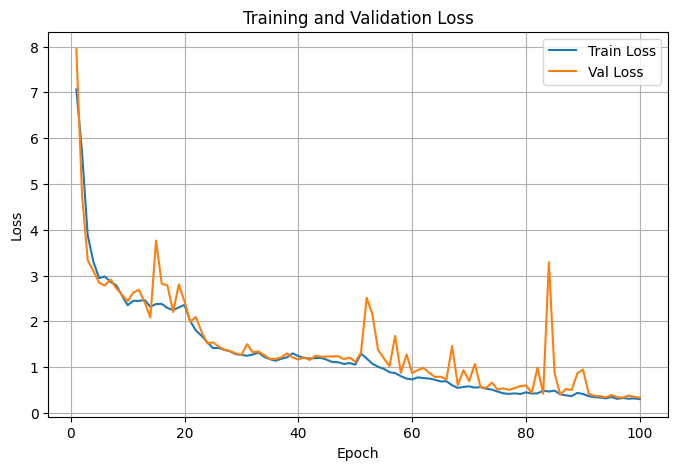

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Train Loss')
plt.plot(epochs, val_loss, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

history and history_fine accuracy plot (The plot corresponds to the model from the first run, which achieved 91% accuracy on the test set)

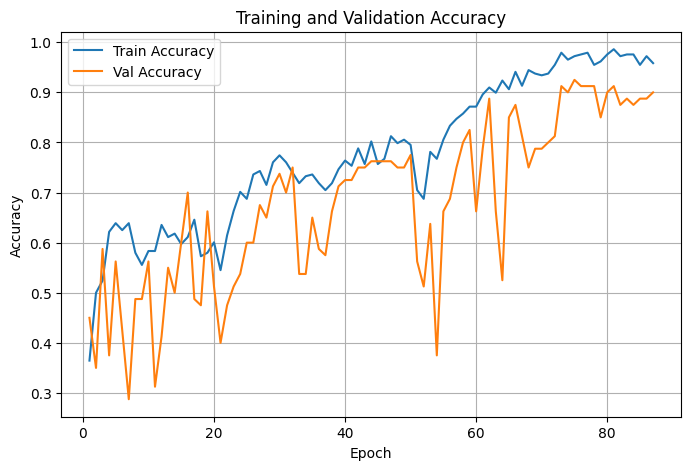

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

And the plot for another model, which achieved 93% accuracy but with a higher loss.

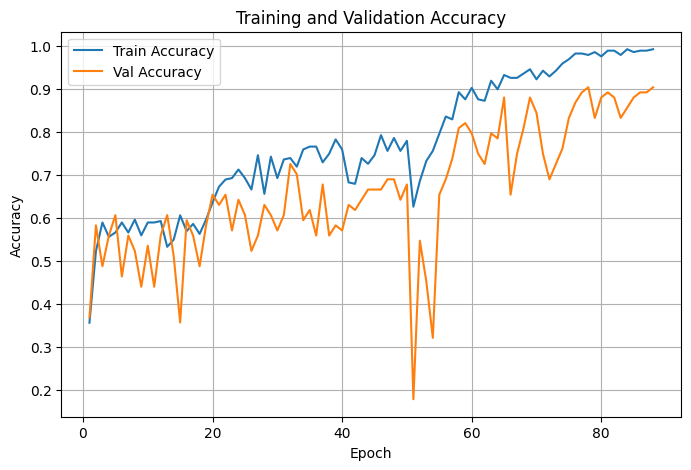

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

After adding Elvin Mahmudzada's data to mine, I achieved almost 95% accuracy, and the loss on the test set decreased to 0.3960, making the model more confident in its predictions. This is the accuracy plot of that model

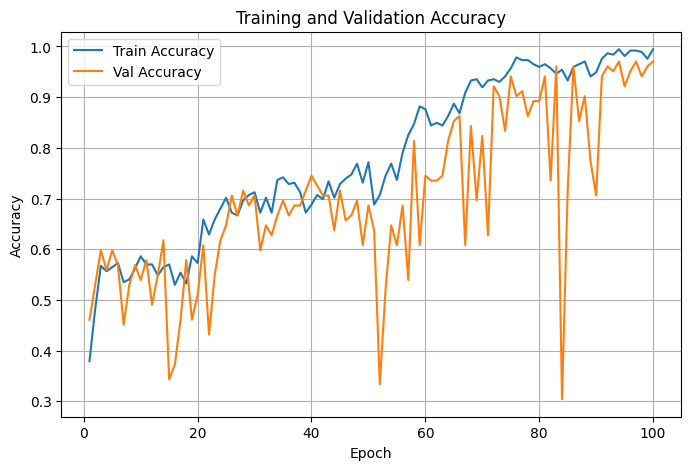

In [71]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label='Train Accuracy')
plt.plot(epochs, val_accuracy, label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Getting true labels and predicted ones

**Loading the model for which we want to check the confusion matrix:**

1. **mobilenetv2_best.keras** – model from the first run, with 91% accuracy and 0.54 loss.
2. **mobilenetv2_best_new.keras** – model from the subsequent runs, with 93% accuracy but higher loss, around 0.8.
3. **mobilenetv2_best_added_elvin.keras** – model after I added Elvin Mahmudzada's data to mine; this one achieved almost 95% accuracy with lower loss, around 0.39.


In [72]:
model_path = os.path.join(save_dir, "mobilenetv2_best_added_elvin.keras" )
model = keras.models.load_model(model_path)

In [73]:
y_true = []
for _, y in test_dataset:
    y_true.extend(np.argmax(y, axis=-1))
y_true = np.array(y_true)

# Predictions
y_pred = model.predict(test_dataset, verbose=1)
y_pred = np.argmax(y_pred, axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 625ms/step


Calculating confusion matrix

In [74]:
cm = confusion_matrix(y_true, y_pred)

Plotting confusion matrix using seaborn

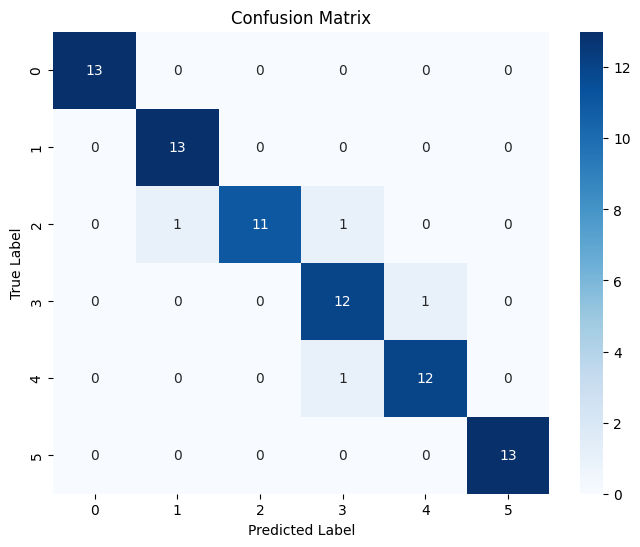

In [75]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=range(cm.shape[1]),
    yticklabels=range(cm.shape[0])
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Visualizing Model Misclassifications

This notebook cell displays only the images where the model made incorrect predictions.

- Images are normalized to [-1, 1] for MobileNetV2, so we convert them to [0, 255] for display.
- True and predicted labels are shown in red text on each image.
- RGB images are converted to BGR format for OpenCV.
- This helps to inspect exactly **where and how the model is making mistakes**, useful for dataset analysis or debugging.


Index: 26, True label: 4, Predicted label: 3


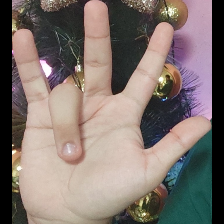

Index: 59, True label: 3, Predicted label: 4


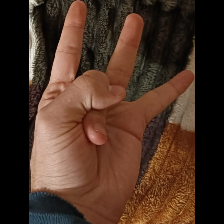

Index: 65, True label: 2, Predicted label: 3


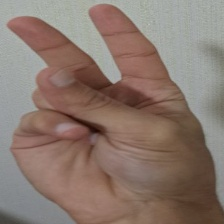

Index: 66, True label: 2, Predicted label: 1


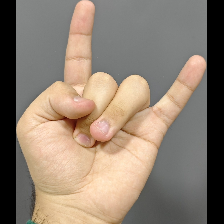

In [76]:
images_list = []
labels_list = []

for img, label in test_dataset:
    images_list.extend(img)
    labels_list.extend(np.argmax(label, axis=-1))

images_list = np.array(images_list)
labels_list = np.array(labels_list)

# Iterate over all predictions
for i in range(len(y_true)):
    if y_true[i] != y_pred[i]:  # only errors
        img = images_list[i].copy()

        # Convert from [-1, 1] to [0, 255] for display
        if img.min() >= -1.0 and img.max() <= 1.0:
            img = ((img + 1) * 127.5).astype(np.uint8)

        # Convert RGB to BGR for OpenCV
        if img.shape[-1] == 3:
            img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

        # Print labels instead of putting text on the image
        print(f"Index: {i}, True label: {y_true[i]}, Predicted label: {y_pred[i]}")

        # Display the image
        cv2_imshow(img)

### Per-Class Performance Analysis

In addition to overall accuracy and the confusion matrix, it is important to evaluate the model's performance **for each class individually**.

The per-class analysis provides metrics such as:

- **Precision**: the proportion of correctly predicted instances among all instances predicted for a class.  
- **Recall**: the proportion of correctly predicted instances among all true instances of a class.  
- **F1-score**: the harmonic mean of precision and recall, providing a balance between the two.  
- **Support**: the number of true instances for each class.

This analysis helps to identify which classes the model predicts well and which classes may require further improvement

The following table is generated using `classification_report` from scikit-learn for all 6 classes.


In [77]:
report = classification_report(y_true, y_pred, digits=3)

In [78]:
print(report)

              precision    recall  f1-score   support

           0      1.000     1.000     1.000        13
           1      0.929     1.000     0.963        13
           2      1.000     0.846     0.917        13
           3      0.857     0.923     0.889        13
           4      0.923     0.923     0.923        13
           5      1.000     1.000     1.000        13

    accuracy                          0.949        78
   macro avg      0.951     0.949     0.949        78
weighted avg      0.951     0.949     0.949        78

